# PHY 321 Honor's Project
## - Siddak Marwaha

# a)

For the four coupled differential equations

$$
\frac{dv_x}{dt}=-\frac{GM_{\odot}}{r^3}x,
$$

$$
\frac{dx}{dt}=v_x,
$$

$$
\frac{dv_y}{dt}=-\frac{GM_{\odot}}{r^3}y,
$$

and

$$
\frac{dy}{dt}=v_y,
$$

We can introduce astronomical units with $1$ AU = $1.5\times 10^{11}$. 

Using the equations of circular motion (with $r =1\mathrm{AU}$)

$$
\frac{M_E v^2}{r} = F = \frac{GM_{\odot}M_E}{r^2},
$$

we have

$$
GM_{\odot}=v^2r,
$$

So, velocity of the Earth is

$$v = 2\pi r/\mathrm{yr}=2\pi\mathrm{AU}/\mathrm{yr}$$ and we have 
$$
GM_{\odot}= v^2r = 4\pi^2 \frac{(\mathrm{AU})^3}{\mathrm{yr}^2}.
$$

The four coupled differential equations can then be discretized using Euler's method as (with step length $h$)

$$
v_{x,i+1}=v_{x,i}-h\frac{4\pi^2}{r_i^3}x_i,
$$

and

$$
x_{i+1}=x_i+hv_{x,i},
$$

and

$$
v_{y,i+1}=v_{y,i}-h\frac{4\pi^2}{r_i^3}y_i,
$$

and

$$
y_{i+1}=y_i+hv_{y,i},
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import *
import time

### Euler's Method

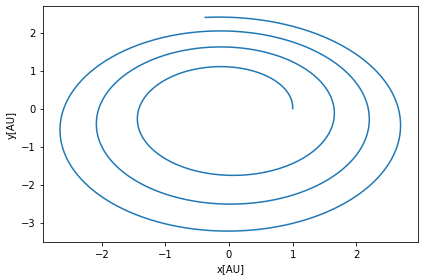

In [2]:
DeltaT = 0.01
#set up arrays 
tfinal = 10 # in years
n = ceil(tfinal/DeltaT)
# set up arrays for t, v, and x
t = np.zeros(n)
v = np.zeros((n,2))
r = np.zeros((n,2))
# Initial conditions as compact 2-dimensional arrays
r0 = np.array([1.0,0.0])
v0 = np.array([0.0,2*pi])
r[0] = r0
v[0] = v0
Fourpi2 = 4*pi*pi
# Start integrating using Euler's method
for i in range(n-1):
    rabs = sqrt(sum(r[i]*r[i]))
    a =  -Fourpi2*r[i]/(rabs**3)
    # update velocity, time and position using Euler's forward method
    v[i+1] = v[i] + DeltaT*a
    r[i+1] = r[i] + DeltaT*v[i]
    t[i+1] = t[i] + DeltaT
# Plot position as function of time    
fig, ax = plt.subplots()
ax.set_xlabel('x[AU]')
ax.set_ylabel('y[AU]')
ax.plot(r[:,0], r[:,1])
fig.tight_layout()
plt.show()

Euler's Forward Algorithm doesn't seem to work (with dt = 0.01) well since it doesn't conserve Energy.

### Velocity Verlet

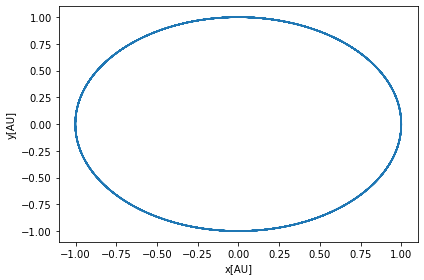

In [3]:
DeltaT = 0.01
#set up arrays 
tfinal = 10
n = ceil(tfinal/DeltaT)
# set up arrays for t, v, and r
t = np.zeros(n)
v = np.zeros((n,2))
r = np.zeros((n,2))
# Initial conditions as compact 2-dimensional arrays
r0 = np.array([1.0,0.0])
v0 = np.array([0.0,2*pi])
r[0] = r0
v[0] = v0
Fourpi2 = 4*pi*pi
# Start integrating using the Velocity-Verlet  method
for i in range(n-1):
    rabs = sqrt(sum(r[i]*r[i]))
    a =  -Fourpi2*r[i]/(rabs**3)
    # update velocity, time and position using the Velocity-Verlet method
    r[i+1] = r[i] + DeltaT*v[i]+0.5*(DeltaT**2)*a
    rabs = sqrt(sum(r[i+1]*r[i+1]))
    anew = -Fourpi2*r[i+1]/(rabs**3)
    v[i+1] = v[i] + 0.5*DeltaT*(a+anew)
    t[i+1] = t[i] + DeltaT
# Plot position as function of time    
fig, ax = plt.subplots()
ax.set_xlabel('x[AU]')
ax.set_ylabel('y[AU]')
ax.plot(r[:,0], r[:,1])
fig.tight_layout()
plt.show()

Velocity Verlet seems to be working pretty well even with dt = 0.01.

# b) and c)

In [4]:
class Orbit:
    def init(self, r0 = 1, v0 = 2*pi, DeltaT=0.01, tfinal=10, beta = 2):
        self.DeltaT = DeltaT
        self.tfinal = tfinal
        self.n = ceil(self.tfinal/self.DeltaT)
        self.t = np.zeros(self.n)
        self.v = np.zeros((self.n, 2))
        self.r = np.zeros((self.n, 2))
        self.r0 = np.array([r0, 0.0])
        self.v0 = np.array([0.0, v0])
        self.r[0] = self.r0
        self.v[0] = self.v0
        self.Fourpi2 = 4*pi*pi
        self.beta = beta
        
    def acceleration(self, r):
        rabs = sqrt(sum(r*r))
        a = -self.Fourpi2*r/(rabs**(self.beta+1))
        return a

    def euler(self):
        for i in range(self.n-1):
            a = self.acceleration(self.r[i])
            self.v[i+1] = self.v[i] + self.DeltaT*a
            self.r[i+1] = self.r[i] + self.DeltaT*self.v[i]
            self.t[i+1] = self.t[i] + self.DeltaT

    def verlet(self):
        for i in range(self.n-1):
            a = self.acceleration(self.r[i])
            self.r[i+1] = self.r[i] + self.DeltaT*self.v[i] + 0.5*(self.DeltaT**2)*a
            anew = self.acceleration(self.r[i+1])
            self.v[i+1] = self.v[i] + 0.5*self.DeltaT*(a+anew)
            self.t[i+1] = self.t[i] + self.DeltaT

    def plot_orbit(self):
        print('dt =', self.DeltaT)
        fig, ax = plt.subplots(figsize=(8,8))
        ax.set_xlabel('x[AU]')
        ax.set_ylabel('y[AU]')
        ax.plot(self.r[:,0], self.r[:,1])
        fig.tight_layout()
        plt.show()
        
    def calc_energy(self):
        kinetic = 0.5*np.sum(self.v**2, axis=1)
        potential = -self.Fourpi2/np.sqrt(np.sum(self.r**2, axis=1))
        return kinetic, potential, kinetic+potential

    def calc_ang_mom(self):
        L = np.sqrt(np.sum(self.v**2, axis=1))*np.sqrt(np.sum(self.r**2, axis=1))
        return L
    
    def plot_energy(self):
        kinetic, potential, E = self.calc_energy()
        fig, axs = plt.subplots(2, 2, figsize=(12, 8))
        axs[0, 0].plot(self.t, kinetic, label='Kinetic Energy')
        axs[0, 0].set_xlabel('t[yr]')
        axs[0, 0].set_ylabel('Energy [J]')
        axs[0, 0].legend()
        axs[0, 1].plot(self.t, potential, label='Potential Energy')
        axs[0, 1].set_xlabel('t[yr]')
        axs[0, 1].set_ylabel('Energy [J]')
        axs[0, 1].legend()
        axs[1, 0].plot(self.t, E, label='Total Energy')
        axs[1, 0].set_xlabel('t[yr]')
        axs[1, 0].set_ylabel('Energy [J]')
        axs[1, 0].legend()
        L = self.calc_ang_mom()
        axs[1, 1].plot(self.t, L, label = 'Angular Momentum')
        axs[1, 1].set_xlabel('t[yr]')
        axs[1, 1].set_ylabel('Momentum [kgm^2/yr]')
        axs[1, 1].legend()

Euler's Method
dt = 0.01


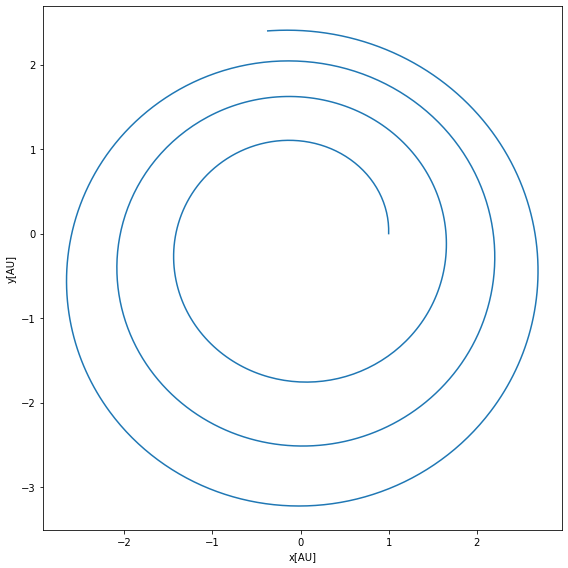

Velocity Verlet Method
dt = 0.01


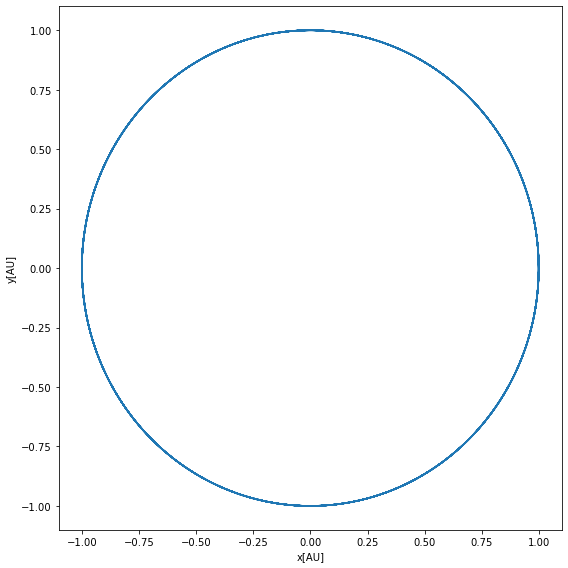

Euler's Method
dt = 0.001


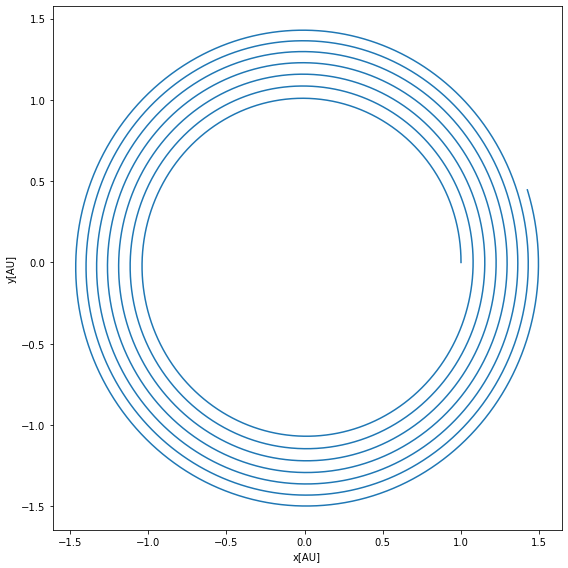

Velocity Verlet Method
dt = 0.001


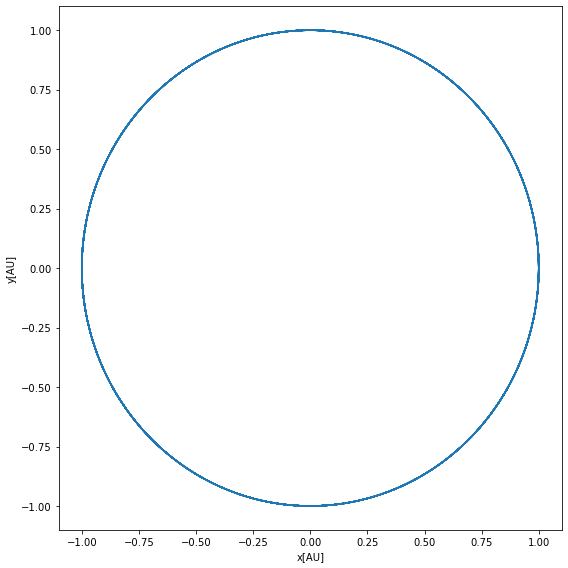

Euler's Method
dt = 0.0001


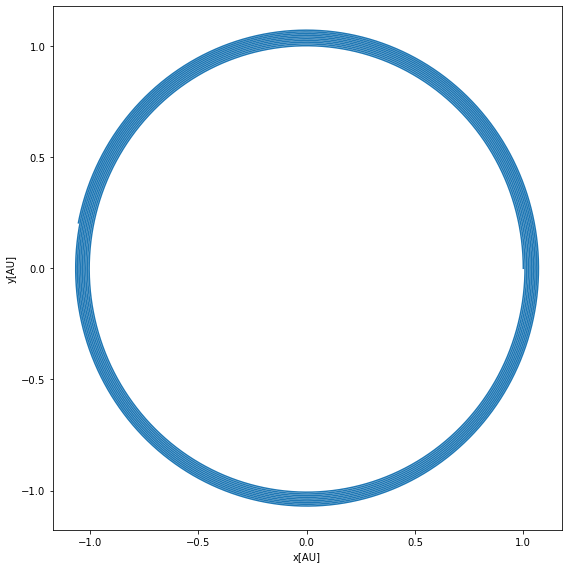

Velocity Verlet Method
dt = 0.0001


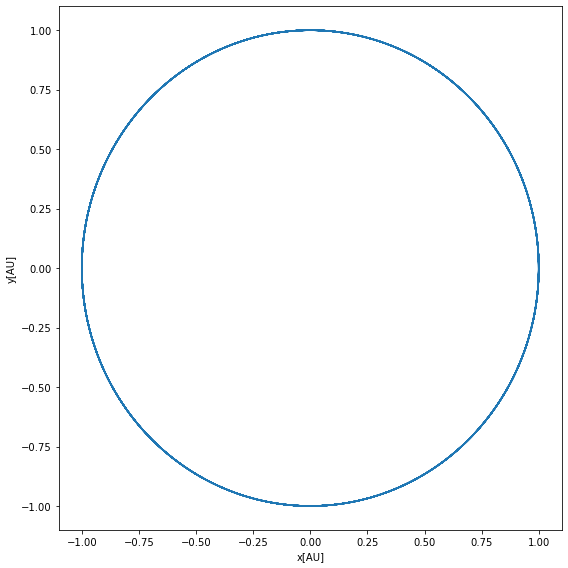

In [5]:
orbit = Orbit()
orbit.init()
orbit.euler()
print('Euler\'s Method')
orbit.plot_orbit()
orbit.verlet()
print('Velocity Verlet Method')
orbit.plot_orbit()

orbit.init(DeltaT=0.001)
orbit.euler()
print('Euler\'s Method')
orbit.plot_orbit()
orbit.verlet()
print('Velocity Verlet Method')
orbit.plot_orbit()

orbit.init(DeltaT=0.0001)
orbit.euler()
print('Euler\'s Method')
orbit.plot_orbit()
orbit.verlet()
print('Velocity Verlet Method')
orbit.plot_orbit()

# orbit.init(0.00001)
# orbit.euler()
# print('Euler\'s Method')
# orbit.plot_orbit()
# orbit.verlet()
# print('Velocity Verlet Method')
# orbit.plot_orbit()


Here, we can see how the Euler's method typically needs a smaller timestep to be able to perform better. However, increasing the timestep compromises with the computation speed so we cant do that much (also something we will talk about soon). Velocity Verlet method works really well even in a higher timestep. 

The initial velocity required for a circular orbit is [[0,2pi]]

Euler's Method
dt = 0.01


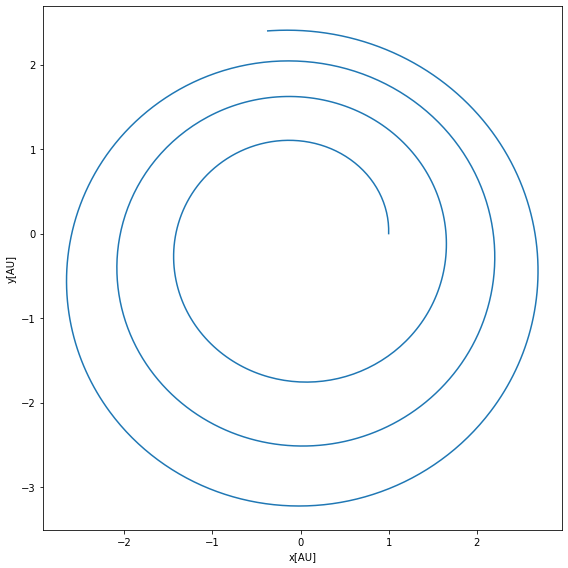

Velocity Verlet Method
dt = 0.01


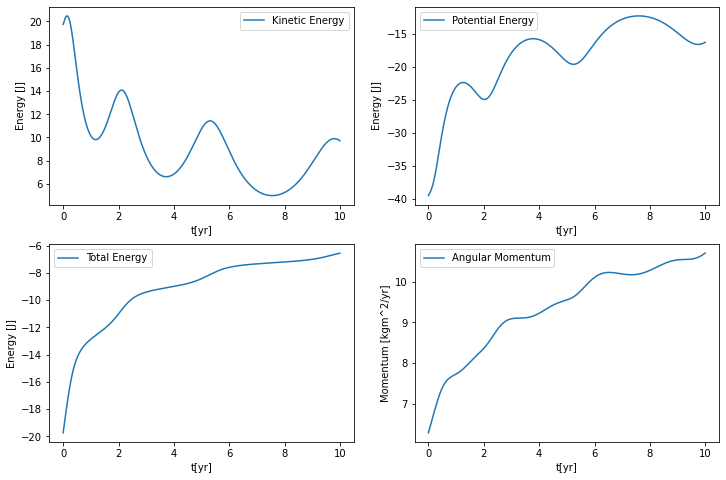

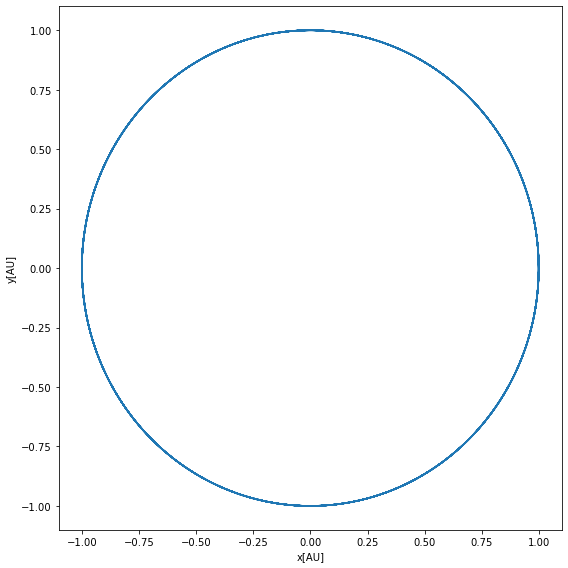

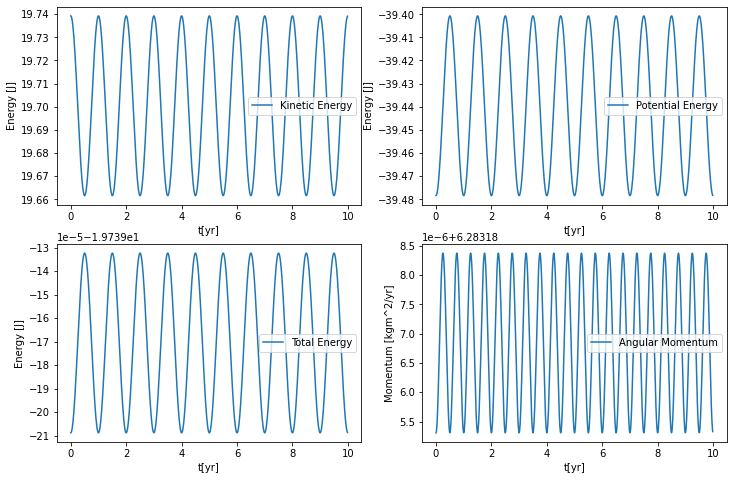

In [6]:
orbit.init()
orbit.euler()
print('Euler\'s Method')
orbit.plot_orbit()
orbit.plot_energy()
orbit.verlet()
print('Velocity Verlet Method')
orbit.plot_orbit()
orbit.plot_energy()


Here, we can see how the total energy increases and becomes less negative in the Euler's Method. However, it seems like the Angular Momentum also increases and becomes more positive. The Potential energy seems to increase and become less negative while the kinetic energy decreases. It does not conserve any of those quantities. At the same timestep, we can see that the velocity verlet method conserves both Total Energy (Only varies at 1e-5) and Angular Momentum (varies at 1e-6). It also  conserves K.E. and P.E. (at a degree of 1e-2).

These quantities should be conserved due to the conservation of energy and momentum laws in physics.

For a circular orbit, the kinetic energy and potential energy should both be conserved because the particle is moving with a constant speed and at a constant distance from the central object. The kinetic energy is given by 1/2 mv^2, where m is the mass of the particle and v is its velocity. Since the speed is constant, the kinetic energy will remain constant. The potential energy is given by -GMm/r, where G is the gravitational constant, M is the mass of the central object, m is the mass of the particle, and r is the distance between them. Since the distance remains constant in a circular orbit, the potential energy will also remain constant.

The angular momentum should also be conserved in a circular orbit because there is no torque acting on the particle. Angular momentum is given by L = r x p, where r is the position vector and p is the momentum vector. In a circular orbit, the position vector and momentum vector are always perpendicular, which means their cross product will always be constant. Therefore, the angular momentum will be conserved.

In [7]:
orbit.init(DeltaT=0.0001)
start_time = time.time()
orbit.euler()
end_time = time.time()
print("Time taken for Euler's method: ", end_time - start_time, 's')

start_time = time.time()
orbit.verlet()
end_time = time.time()
print("Time taken for Verlet's method: ", end_time - start_time, 's')


Time taken for Euler's method:  0.7195799350738525 s
Time taken for Verlet's method:  1.2254669666290283 s


Here, we can see that the time taken to do the Euler's method calculations is less and to do the velocity verlet's calculations is more. Therefore we can conclude that the Verlet's method has more FLOPs than the Euler's method.

# d) 

Velocity Verlet Method
dt = 0.01


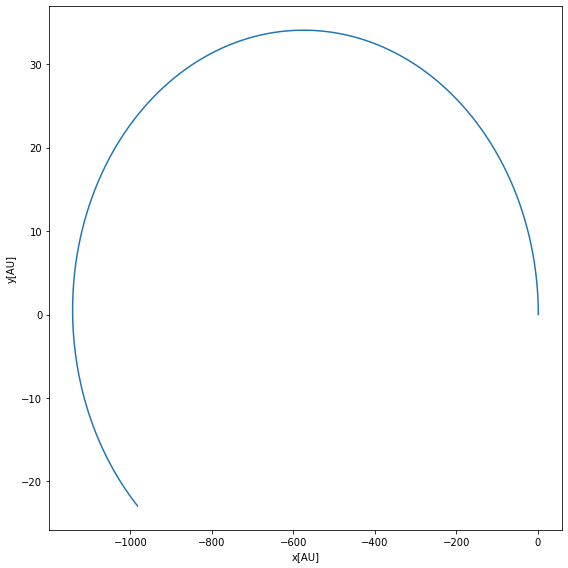

In [8]:
orbit.init(DeltaT=0.01, v0 = 2*pi+2.5965, tfinal=10000)
orbit.verlet()
print('Velocity Verlet Method')
orbit.plot_orbit()

Using trial and error, I found that the initial velocity at which the Earth ends up going out of orbit from the Sun is 

$$2\pi+2.5965 = 8.8797 AU/yr$$ 

Now, the formula for escape velocity is $$v_E = \sqrt{\frac{2GM}{r}}$$
In terms of AU, solar mass, and yr, this ends up being $$v_E = \sqrt{\frac{2*4\pi^2*1}{1}} \\ = \sqrt{8\pi^2}\\ = 8.8858$$

In [9]:
np.sqrt(8*pi**2)

8.885765876316732

The calculated escape velocity seems to be very close to what I got, so my code and calculations seem to have been verified.

Velocity Verlet Method for beta = 2
dt = 0.01


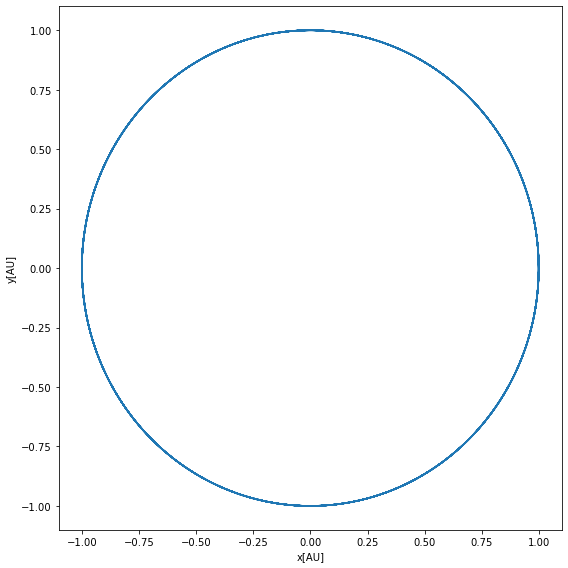

Velocity Verlet Method for beta = 2.5
dt = 0.01


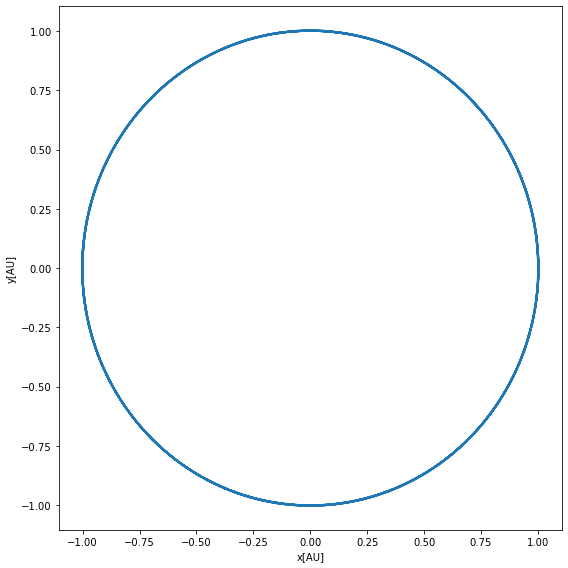

Velocity Verlet Method for beta = 2.9
dt = 0.01


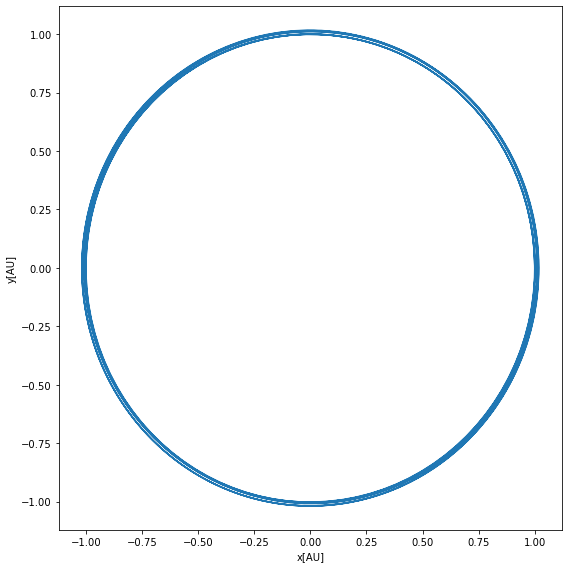

Velocity Verlet Method for beta = 3
dt = 0.01


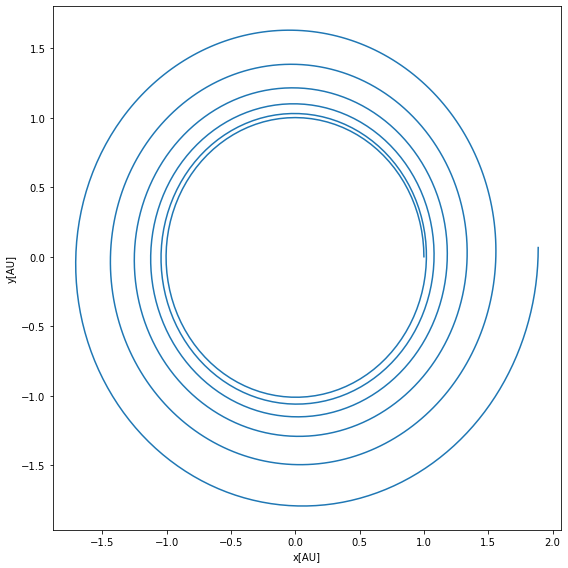

In [10]:
beta = [2, 2.5, 2.9, 3]
for b in beta:
    orbit = Orbit()
    orbit.init(beta = b)
    orbit.verlet()
    print('Velocity Verlet Method for beta =', b)
    orbit.plot_orbit()

When $\beta$ is 2, the orbit seems to be very stable. Now when $\beta$ = 2.5, while very slightly wider, it still seems to be pretty stable. I could say the same with $\beta$ = 2.9, slightly wider but still stable. However, as soon as $\beta$ = 3, we can see that the orbit ends up being very unstable. The Earth seems to go out of orbit when $\beta$ = 3.

So in conclusion, when the force law is an inverse square law (beta=2), the planet moves in a circular orbit, as expected. This is because the gravitational force between two objects decreases as the square of the distance between them. In a circular orbit, the gravitational force is balanced by the centripetal force, resulting in a stable orbit.

However, when the force law is modified to have a beta value of 3, the planet's motion is affected. With beta=3, the force decreases more quickly with distance, causing the planet to slowly spiral outwards over time. This is because the planet is not moving fast enough to maintain a circular orbit, and the gravitational force is not strong enough to keep the planet in a stable orbit. Instead, the planet moves in a spiraling path away from the central object.

# e)

In [11]:
class Orbit:
    def init(self, re0 = 1, ve0 = 2*pi, DeltaT=0.01, tfinal=10, beta = 2, M = 0.00095, rj0 = 5.2, 
             vj0 = 2*pi/sqrt(5.2), mj = 0.00095):
        self.DeltaT = DeltaT
        self.tfinal = tfinal
        self.n = ceil(self.tfinal/self.DeltaT)
        self.t = np.zeros(self.n)
        self.ve = np.zeros((self.n,2))
        self.re = np.zeros((self.n,2))
        self.vj = np.zeros((self.n,2))
        self.rj = np.zeros((self.n,2))
        self.m_earth = 3e-6
        self.mj = mj
        self.re0 = np.array([re0,0.0])
        self.ve0 = np.array([0.0,ve0])
        self.rj0 = np.array([rj0,0.0])
        self.vj0 = np.array([0.0,vj0])
        self.re[0] = self.re0
        self.ve[0] = self.ve0
        self.rj[0] = self.rj0
        self.vj[0] = self.vj0
        self.beta = beta
        self.M = M
        
        
    def acceleration(self, rj, re):
        r_ej = np.linalg.norm(rj - re)
        reabs = sqrt(sum(re*re))
        rjabs = sqrt(sum(rj*rj))
        ae = -Fourpi2*re/(reabs**(self.beta+1)) - Fourpi2*self.mj*(re-rj)/r_ej**(self.beta+1)
        aj = -Fourpi2*rj/(rjabs**(self.beta+1)) - Fourpi2*self.m_earth*(re-rj)/r_ej**(self.beta+1)
        return ae, aj

    def verlet(self):
        for i in range(self.n-1):
            ae, aj = self.acceleration(self.rj[i], self.re[i])
            self.re[i+1] = self.re[i] + DeltaT*self.ve[i]+0.5*(DeltaT**2)*ae
            self.rj[i+1] = self.rj[i] + DeltaT*self.vj[i]+0.5*(DeltaT**2)*aj
            aenew, ajnew = self.acceleration(self.rj[i+1], self.re[i+1])
            self.ve[i+1] = self.ve[i] + 0.5*DeltaT*(ae+aenew)
            self.vj[i+1] = self.vj[i] + 0.5*DeltaT*(aj+ajnew)
            self.t[i+1] = self.t[i] + self.DeltaT

    def plot_orbit(self):
        print('dt =', self.DeltaT, '\n',
             'Mass of Jupiter =', self.mj, 'Solar Masses')
        fig, ax = plt.subplots(figsize=(8,8))
        ax.set_xlabel('x[AU]')
        ax.set_ylabel('y[AU]')
        ax.plot(self.re[:,0], self.re[:,1], label = 'Earth')
        ax.plot(self.rj[:,0], self.rj[:,1], label = 'Jupiter')
        plt.legend()
        plt.show()
        
    def calc_energy(self):
        kinetic = 0.5*np.sum(self.v**2, axis=1)
        potential = -self.Fourpi2/np.sqrt(np.sum(self.r**2, axis=1))
        return kinetic, potential, kinetic+potential

    def calc_ang_mom(self):
        L = np.sqrt(np.sum(self.v**2, axis=1))*np.sqrt(np.sum(self.r**2, axis=1))
        return L
    
    def plot_energy(self):
        kinetic, potential, E = self.calc_energy()
        fig, axs = plt.subplots(2, 2, figsize=(12, 8))
        axs[0, 0].plot(self.t, kinetic, label='Kinetic Energy')
        axs[0, 0].set_xlabel('t[yr]')
        axs[0, 0].set_ylabel('Energy [J]')
        axs[0, 0].legend()
        axs[0, 1].plot(self.t, potential, label='Potential Energy')
        axs[0, 1].set_xlabel('t[yr]')
        axs[0, 1].set_ylabel('Energy [J]')
        axs[0, 1].legend()
        axs[1, 0].plot(self.t, E, label='Total Energy')
        axs[1, 0].set_xlabel('t[yr]')
        axs[1, 0].set_ylabel('Energy [J]')
        axs[1, 0].legend()
        L = self.calc_ang_mom()
        axs[1, 1].plot(self.t, L, label = 'Angular Momentum')
        axs[1, 1].set_xlabel('t[yr]')
        axs[1, 1].set_ylabel('Momentum [kgm^2/yr]')
        axs[1, 1].legend()

dt = 0.01 
 Mass of Jupiter = 0.00095 Solar Masses


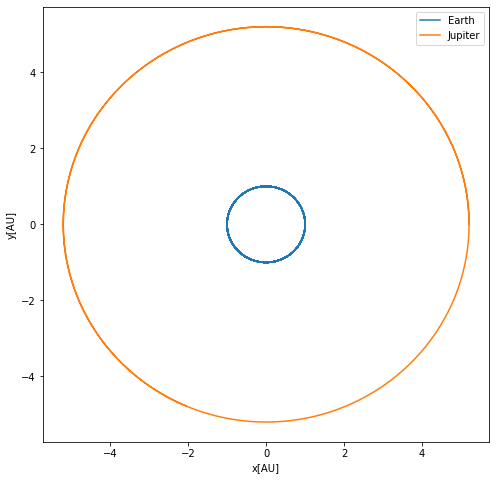

dt = 0.01 
 Mass of Jupiter = 0.0095 Solar Masses


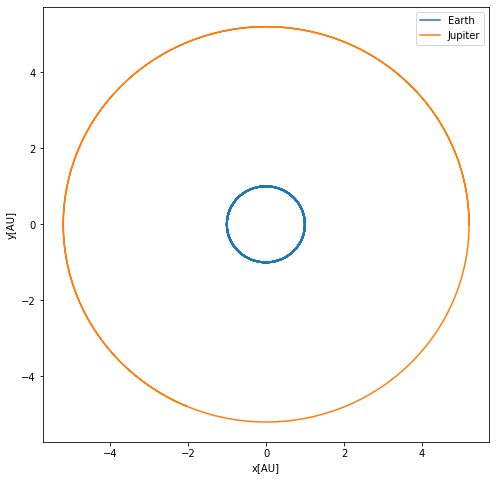

dt = 0.01 
 Mass of Jupiter = 0.95 Solar Masses


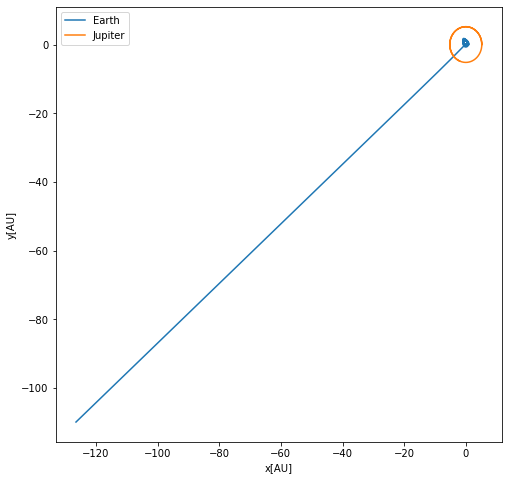

In [12]:
orbit = Orbit()
orbit.init(tfinal=20)
orbit.verlet()
orbit.plot_orbit()

orbit.init(mj = 0.0095, tfinal=20)
orbit.verlet()
orbit.plot_orbit()

orbit.init(mj = 0.95, tfinal=20)
orbit.verlet()
orbit.plot_orbit()

The Orbits of Earth and Jupiter seemed perfectly fine and circular when their original masses were put. When I increase Jupiter's mass by 10, it still seems to have a stable orbit. However, when the mass is increased by a factor of 1000, we can clearly see that the Earth is put out of orbit due to Jupiter's mass.

# f)

In [20]:
class Orbit:
    def __init__(self, planet_data, DeltaT=0.01, tfinal=10, beta=2):
        self.DeltaT = DeltaT
        self.tfinal = tfinal
        self.beta = beta
        
        # Extract the planet positions and velocities from the planet_data dictionary
        self.names = list(planet_data.keys())
        self.positions = np.array([planet_data[name]['position'] for name in self.names])
        self.velocities = np.array([planet_data[name]['velocity'] for name in self.names])
        self.masses = np.array([planet_data[name]['mass'] for name in self.names])
        self.num_planets = len(self.names)
        
        # Calculate the center of mass position and velocity
        self.total_mass = np.sum(self.masses)
        self.center_of_mass = np.sum(self.masses[:, np.newaxis] * self.positions, axis=0) / self.total_mass
        self.vel_center_of_mass = np.sum(self.masses[:, np.newaxis] * self.velocities, axis=0) / self.total_mass
        
        # Convert positions and velocities to center-of-mass frame
        self.positions -= self.center_of_mass
        self.velocities -= self.vel_center_of_mass
        
        # Initialize arrays to store positions and velocities
        self.n = ceil(self.tfinal/self.DeltaT)
        self.t = np.zeros(self.n)
        self.positions_array = np.zeros((self.n, self.num_planets, 2))
        self.velocities_array = np.zeros((self.n, self.num_planets, 2))
        
        # Set initial positions and velocities
        self.positions_array[0] = self.positions
        self.velocities_array[0] = self.velocities
        
    def acceleration(self, positions):
        num_planets = len(positions)
        acceleration = np.zeros_like(positions)
        G = Fourpi2
        for i in range(num_planets):
            for j in range(num_planets):
                if i != j:
                    r = positions[j] - positions[i]
                    r_mag = np.linalg.norm(r)
                    acceleration[i] += G * self.masses[j] * r / r_mag**(self.beta+1)
        return acceleration
        
    def verlet(self):
        for i in range(self.n-1):
                acceleration = self.acceleration(self.positions_array[i])
                self.positions_array[i+1] = self.positions_array[i] + self.velocities_array[i]*self.DeltaT + 0.5*acceleration*self.DeltaT**2
                acceleration_new = self.acceleration(self.positions_array[i+1])
                self.velocities_array[i+1] = self.velocities_array[i] + 0.5*(acceleration + acceleration_new)*self.DeltaT
                self.t[i+1] = self.t[i] + self.DeltaT
            
    def plot_orbit(self):
        fig, ax = plt.subplots(figsize=(8,8))
        ax.set_xlabel('x [AU]')
        ax.set_ylabel('y [AU]')
        for i in range(self.num_planets):
            ax.plot(self.positions_array[:, i, 0], self.positions_array[:, i, 1], label=self.names[i])
        plt.legend()
        plt.show()


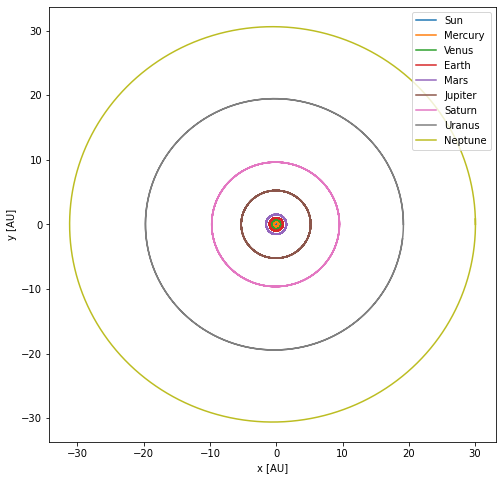

In [21]:
solar_mass = 1.989e30
planet_data = {
    'Sun': {'mass': 1.989e30/solar_mass, 'position': np.array([0, 0]), 'velocity': np.array([0, -1.469e-02])},
    'Mercury': {'mass': 3.3e23/solar_mass, 'position': np.array([0.39, 0]), 'velocity': np.array([0, np.sqrt(4*pi*pi/0.39)])},
    'Venus': {'mass': 4.9e24/solar_mass, 'position': np.array([0.72, 0]), 'velocity': np.array([0, np.sqrt(4*pi*pi/0.72)])},
    'Earth': {'mass': 6e24/solar_mass, 'position': np.array([1, 0]), 'velocity': np.array([0, np.sqrt(4*pi*pi/1)])},
    'Mars': {'mass': 6.6e23/solar_mass, 'position': np.array([1.52, 0]), 'velocity': np.array([0, np.sqrt(4*pi*pi/1.52)])},
    'Jupiter': {'mass': 1.9e27/solar_mass, 'position': np.array([5.2, 0]), 'velocity': np.array([0, np.sqrt(4*pi*pi/5.2)])},
    'Saturn': {'mass': 5.5e26/solar_mass, 'position': np.array([9.54, 0]), 'velocity': np.array([0, np.sqrt(4*pi*pi/9.54)])},
    'Uranus': {'mass': 8.8e25/solar_mass, 'position': np.array([19.19, 0]), 'velocity': np.array([0, np.sqrt(4*pi*pi/19.19)])},
    'Neptune': {'mass': 1.03e26/solar_mass, 'position': np.array([30.06, 0]), 'velocity': np.array([0, np.sqrt(4*pi*pi/30.06)])}
}
solar_system = Orbit(planet_data, DeltaT=0.01, tfinal=170)
solar_system.verlet()
solar_system.plot_orbit()


The results show that the planets follow orbits around the Sun, as predicted by Kepler's laws. The inner planets, such as Mercury and Venus, have much shorter orbital periods than the outer planets, such as Jupiter and Saturn. This is due to their closer proximity to the Sun and the stronger gravitational force experienced. Overall, the simulation successfully models the basic behavior of our solar system, and can be further extended to include more celestial objects and refine the accuracy of the model.

# g)

In [92]:
class Orbit:
    def __init__(self, planet_data, DeltaT=0.01, tfinal=10, beta=2):
        self.DeltaT = DeltaT
        self.tfinal = tfinal
        self.beta = beta
        
        # Extract the planet positions and velocities from the planet_data dictionary
        self.names = list(planet_data.keys())
        self.positions = np.array([planet_data[name]['position'] for name in self.names])
        self.velocities = np.array([planet_data[name]['velocity'] for name in self.names])
        self.masses = np.array([planet_data[name]['mass'] for name in self.names])
        self.num_planets = len(self.names)
        
        # Calculate the center of mass position and velocity
        self.total_mass = np.sum(self.masses)
        self.center_of_mass = np.sum(self.masses[:, np.newaxis] * self.positions, axis=0) / self.total_mass
        self.vel_center_of_mass = np.sum(self.masses[:, np.newaxis] * self.velocities, axis=0) / self.total_mass
        
        # Convert positions and velocities to center-of-mass frame
        self.positions -= self.center_of_mass
        self.velocities -= self.vel_center_of_mass
        
        # Initialize arrays to store positions and velocities
        self.n = ceil(self.tfinal/self.DeltaT)
        self.t = np.zeros(self.n)
        self.positions_array = np.zeros((self.n, self.num_planets, 2))
        self.velocities_array = np.zeros((self.n, self.num_planets, 2))
        self.positions_arrayM = np.zeros((self.n, self.num_planets, 2))
        self.velocities_arrayM = np.zeros((self.n, self.num_planets, 2))
        
        # Set initial positions and velocities
        self.positions_array[0] = self.positions
        self.velocities_array[0] = self.velocities
        self.positions_arrayM[0] = self.positions
        self.velocities_arrayM[0] = self.velocities
        
    def accelerationM(self, positions):
        num_planets = len(positions)
        accelerationM = np.zeros_like(positions)
        G = 4*pi*pi
        c = 63197.8
        for i in range(num_planets):
            for j in range(num_planets):
                if i != j:
                    r = positions[j] - positions[i]
                    L = np.sqrt(np.sum(self.positions_array[j]**2, axis=1))*np.sqrt(np.sum(self.velocities_array[j]**2, axis=1))
                    r_mag = np.linalg.norm(r)
                    accelerationM[i] += G * self.masses[j] * r / r_mag**(self.beta+1) * (1+3*L**2/(r_mag**2*c**2))
        return accelerationM

    def acceleration(self, positions):
        num_planets = len(positions)
        acceleration = np.zeros_like(positions)
        G = 4*pi*pi
        c = 63197.8
        for i in range(num_planets):
            for j in range(num_planets):
                if i != j:
                    r = positions[j] - positions[i]
                    r_mag = np.linalg.norm(r)
                    acceleration[i] += G * self.masses[j] * r / r_mag**(self.beta+1) 
        return acceleration
        
    def verletM(self):
        for i in range(self.n-1):
                accelerationM = self.accelerationM(self.positions_arrayM[i])
                self.positions_arrayM[i+1] = self.positions_arrayM[i] + self.velocities_arrayM[i]*self.DeltaT + 0.5*accelerationM*self.DeltaT**2
                accelerationM_new = self.accelerationM(self.positions_arrayM[i+1])
                self.velocities_arrayM[i+1] = self.velocities_arrayM[i] + 0.5*(accelerationM + accelerationM_new)*self.DeltaT
                self.t[i+1] = self.t[i] + self.DeltaT
    def verlet(self):
        for i in range(self.n-1):
                acceleration = self.acceleration(self.positions_array[i])
                self.positions_array[i+1] = self.positions_array[i] + self.velocities_array[i]*self.DeltaT + 0.5*acceleration*self.DeltaT**2
                acceleration_new = self.acceleration(self.positions_array[i+1])
                self.velocities_array[i+1] = self.velocities_array[i] + 0.5*(acceleration + acceleration_new)*self.DeltaT
                self.t[i+1] = self.t[i] + self.DeltaT
            
    def plot_orbit(self):
        fig, ax = plt.subplots(figsize=(8,8))
        ax.set_xlabel('x [AU]')
        ax.set_ylabel('y [AU]')
        for i in range(self.num_planets):
            ax.plot(self.positions_array[:, i, 0], self.positions_array[:, i, 1], label=self.names[i], color = 'r')
            ax.plot(self.positions_arrayM[:, i, 0], self.positions_arrayM[:, i, 1], label=self.names[i], color = 'b')
#         plt.xlim(0,0.02)
#         plt.ylim(-0.4,-0.39)
        plt.legend()
        plt.show()
        

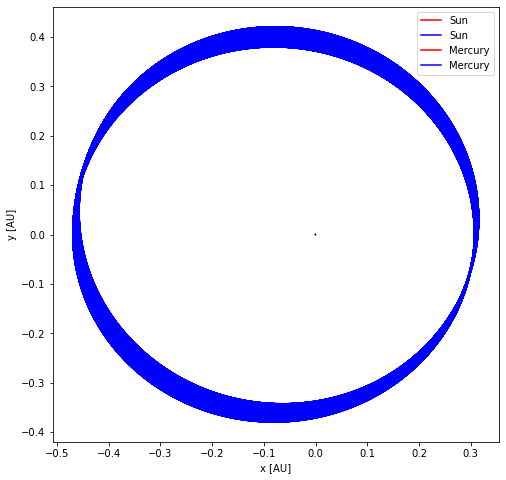

Perihelion Precision with Newtonian force: -1.5707961608823782
Perihelion Precision Observed: -1.57079616088246


In [102]:
solar_mass = 1.989e30
planet_data = {
    'Sun': {'mass': 1.989e30/solar_mass, 'position': np.array([0, 0]), 'velocity': np.array([0, -1.469e-02])},
    'Mercury': {'mass': 3.3e23/solar_mass, 'position': np.array([0.3075, 0]), 'velocity': np.array([0, 12.44])},
}
solar_system = Orbit(planet_data, DeltaT=0.001, tfinal=100)
solar_system.verlet()
solar_system.verletM()
solar_system.plot_orbit()
x_p = np.sum(solar_system.positions_array[:, 0])
y_p = np.sum(solar_system.positions_array[:, 1])
print('Perihelion Precision with Newtonian force:', np.arctan(y_p/x_p))
x_pM = np.sum(solar_system.positions_arrayM[:, 0])
y_pM = np.sum(solar_system.positions_arrayM[:, 1])
print('Perihelion Precision Observed:', np.arctan(y_pM/x_pM))

Here, we can see that the perihelion precession we get with a pure Newtonian force is at least a few orders of
magnitude smaller than the observed perihelion precession of Mercury. So, yes, the observed perihelion precession of Mercury can be explained by the general theory of relativity. 